Real spacecraft telemetry from NASA's SMAP (Soil Moisture Active Passive) satellite and the MSL Curiosity rover. Anomalies were labeled by NASA JPL experts.

**Files (in SMAP/ and MSL/)**

## NASA SMAP & MSL Telemetry Anomalies

In [3]:
import numpy as np

train = np.load("Track 2/SMAP/SMAP_train.npy")
test = np.load("Track 2/SMAP/SMAP_test.npy")
labels = np.load("Track 2/SMAP/SMAP_test_label.npy")

print(train.shape, test.shape, labels.shape)
print(f"{labels.mean():.1%} of test timesteps are anomalous")

(135183, 25) (427617, 25) (427617,)
12.8% of test timesteps are anomalous


In [5]:
%pip install pandas
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.7 MB/s  0:00:00a 0:00:010:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]━━━━━━━━━━━ 2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 16.5 MB/s  0:00:02 eta 0:00:010:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 16.9 MB/s  0:00:007.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 16.4 MB/s  0:00:00 17.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 15.3 MB/s  0:00:00a 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ourpy]
Note: you may need to restart the kernel to use updated packages.


## NASA Li-ion Battery Aging

In [7]:
import numpy as np
from scipy.io import loadmat

cycles = loadmat("Track 2/Battery Aging/5.+Battery+Data+Set/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat", simplify_cells=True)["B0005"]["cycle"]
capacity = np.array([c["data"]["Capacity"] for c in cycles if c["type"] == "discharge"])

print(f"{len(capacity)} discharge cycles, start {capacity[0]:.2f} Ah, end {capacity[-1]:.2f} Ah")

168 discharge cycles, start 1.86 Ah, end 1.33 Ah


In [10]:
cycles = loadmat("Track 2/Battery Aging/5.+Battery+Data+Set/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat", simplify_cells=True)["B0005"]["cycle"]
capacity = np.array([c["data"]["Capacity"] for c in cycles if c["type"] == "discharge"])


cycle_num = np.arange(1, len(capacity) + 1)

print("Discharge cycles:", len(capacity))
print("Starting capacity:", capacity[0])
print("Final capacity:", capacity[-1])

Discharge cycles: 168
Starting capacity: 1.8564874208181574
Final capacity: 1.3250793286429356


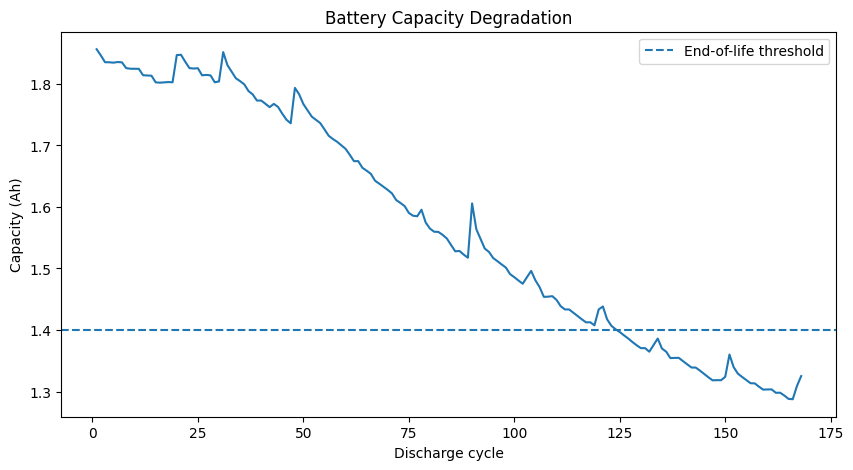

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cycle_num, capacity)
plt.axhline(1.4, linestyle="--", label="End-of-life threshold")
plt.xlabel("Discharge cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Battery Capacity Degradation")
plt.legend()
plt.show()

In [14]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 16.4 MB/s  0:00:00 17.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# x = cycle number
cycle_num = np.arange(1, len(capacity) + 1)

# sklearn expects X to be 2D
X = cycle_num.reshape(-1, 1)
y = capacity

model = LinearRegression()
model.fit(X, y)

predicted_capacity = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R²:", model.score(X, y))

Slope: -0.003866614488401865
Intercept: 1.8992309885417111
R²: 0.9756281929050116


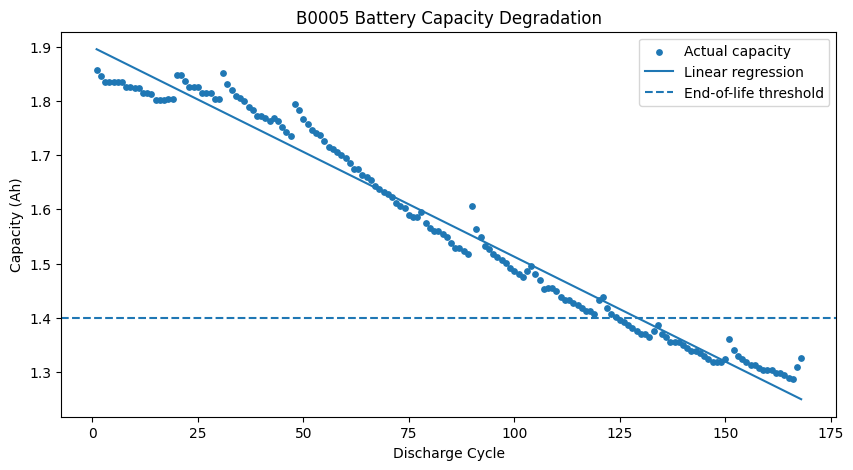

In [16]:
plt.figure(figsize=(10, 5))

plt.scatter(cycle_num, capacity, s=15, label="Actual capacity")
plt.plot(cycle_num, predicted_capacity, label="Linear regression")
plt.axhline(1.4, linestyle="--", label="End-of-life threshold")

plt.xlabel("Discharge Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("B0005 Battery Capacity Degradation")
plt.legend()
plt.show()

In [17]:
EOL_CAPACITY = 1.4

slope = model.coef_[0]
intercept = model.intercept_

failure_cycle = (EOL_CAPACITY - intercept) / slope

print(f"Predicted end-of-life cycle: {failure_cycle:.1f}")

Predicted end-of-life cycle: 129.1


In [18]:
current_cycle = 100

rul = failure_cycle - current_cycle

print(f"At cycle {current_cycle}:")
print(f"Estimated remaining useful life: {rul:.1f} cycles")

At cycle 100:
Estimated remaining useful life: 29.1 cycles


In [19]:
EOL_CAPACITY = 1.4

eol_indices = np.where(capacity <= EOL_CAPACITY)[0]

if len(eol_indices) > 0:
    actual_eol_cycle = cycle_num[eol_indices[0]]
    print(f"Actual EOL cycle: {actual_eol_cycle}")
else:
    print("Battery never reached the 1.4 Ah threshold in the dataset.")

Actual EOL cycle: 125


In [20]:
EOL_CAPACITY = 1.4
CONSECUTIVE_CYCLES = 3

actual_eol_cycle = None

for i in range(len(capacity) - CONSECUTIVE_CYCLES + 1):
    window = capacity[i:i + CONSECUTIVE_CYCLES]

    if np.all(window <= EOL_CAPACITY):
        actual_eol_cycle = cycle_num[i]
        break

if actual_eol_cycle is not None:
    print(f"Actual EOL cycle: {actual_eol_cycle}")
else:
    print("Battery never stayed below the EOL threshold long enough.")

Actual EOL cycle: 125


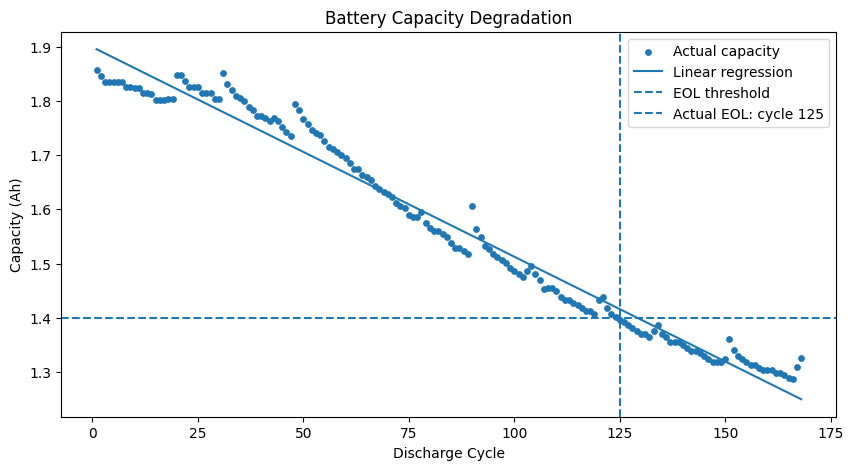

In [21]:
plt.figure(figsize=(10, 5))

plt.scatter(cycle_num, capacity, s=15, label="Actual capacity")
plt.plot(cycle_num, predicted_capacity, label="Linear regression")
plt.axhline(1.4, linestyle="--", label="EOL threshold")

if actual_eol_cycle is not None:
    plt.axvline(
        actual_eol_cycle,
        linestyle="--",
        label=f"Actual EOL: cycle {actual_eol_cycle}"
    )

plt.xlabel("Discharge Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Battery Capacity Degradation")
plt.legend()
plt.show()

In [22]:
if actual_eol_cycle is not None:
    error = failure_cycle - actual_eol_cycle

    print(f"Predicted EOL: {failure_cycle:.1f}")
    print(f"Actual EOL: {actual_eol_cycle}")
    print(f"Error: {error:.1f} cycles")
    print(f"Absolute error: {abs(error):.1f} cycles")

Predicted EOL: 129.1
Actual EOL: 125
Error: 4.1 cycles
Absolute error: 4.1 cycles
